In [23]:
import os
print("Current Working Directory:")
print(os.getcwd())

import os

os.chdir(r"C:\Users\vinay kumar\OneDrive\Documents\vinay\ML_Project\ai-workplace-productivity-analysis")

print(os.getcwd())
print(os.listdir("data"))



Current Working Directory:
C:\Users\vinay kumar\OneDrive\Documents\vinay\ML_Project\ai-workplace-productivity-analysis
C:\Users\vinay kumar\OneDrive\Documents\vinay\ML_Project\ai-workplace-productivity-analysis
['train.csv']


In [27]:
df = pd.read_csv("data/train.csv")

In [30]:
from sklearn.preprocessing import LabelEncoder

# Create a dictionary to store encoders for each column
encoders = {}

for col in df.columns:
    # Check for both 'object' and 'str' dtypes (handles different pandas versions)
    if df[col].dtype == "object" or df[col].dtype == "string" or str(df[col].dtype) == "str":
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        encoders[col] = le  # Store encoder for future use if 
        
X = df.drop("Stress_Level", axis=1)
y = df["Stress_Level"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

X = df.drop("Stress_Level", axis=1)
y = df["Stress_Level"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Diagnostic: Check data types and unique values
print("Data types in X_train:")
print(X_train.dtypes)
print("\nColumns with object dtype:")
for col in X_train.columns:
    if X_train[col].dtype == "object":
        print(f"{col}: {X_train[col].unique()}")

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



Data types in X_train:
Employee_Id                    int64
Avg_Working_Hours_Per_Day    float64
Work_From                      int64
Work_Pressure                  int64
Manager_Support                int64
Sleeping_Habit                 int64
Exercise_Habit                 int64
Job_Satisfaction               int64
Work_Life_Balance              int64
Social_Person                  int64
Lives_With_Family              int64
Working_State                  int64
dtype: object

Columns with object dtype:


In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X_train, y_train)

y_pred_lr = model_lr.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr, average='weighted'))
print("Recall:", recall_score(y_test, y_pred_lr, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred_lr, average='weighted'))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))

Accuracy: 0.20333333333333334
Precision: 0.20755799910745582
Recall: 0.20333333333333334
F1 Score: 0.18875831545103994
Confusion Matrix:
 [[26 29  6 33 30]
 [24 25  1 18 33]
 [27 32  4 29 37]
 [ 9 33  6 33 42]
 [25 38  3 23 34]]


c:\Users\vinay kumar\OneDrive\Documents\vinay\ML_Project\ai-workplace-productivity-analysis\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


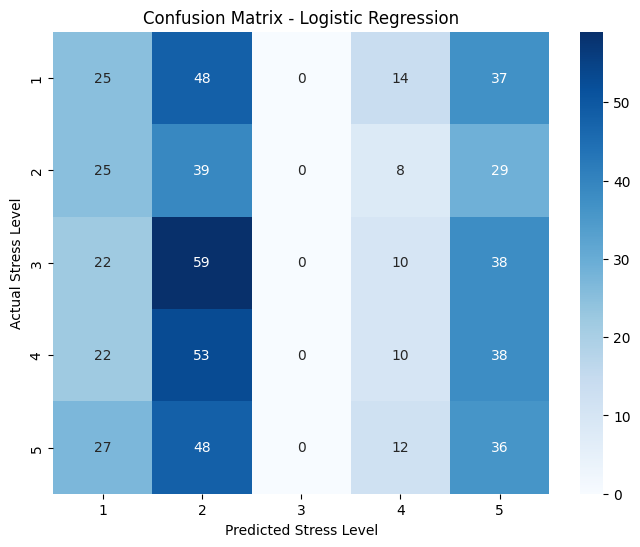

In [33]:
# 10. Confusion Matrix Visualization
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.xlabel('Predicted Stress Level')
plt.ylabel('Actual Stress Level')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()